# Trabajo Práctico 2

## Modelo predictivo de lluvia en Australia

### Facultad de Ciencias Exactas, Ingenieria y Agrimensura (FCEIA) - Universidad Nacional de Rosario (UNR)

**Integrantes:**
| Nombre | Legajo |
|----------|-------|
| Chiappe, Maximiliano | C-7542/6 |
| Lenarduzzi, Juan | L-3398/7 |
---



## Configuración del Entorno

In [62]:
# ── Librerías generales ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn: preprocesamiento ───────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer

# ── Scikit-learn: regresión logística ────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

---

## Carga e Inspección del Dataset

In [2]:
df = pd.read_csv('weatherAUS_2026C1.csv')

print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria utilizada: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB') # Esto les va a servir cuando tengan un dataset muy pesado :)
print()
df.head(5)

Dimensiones del dataset: 145412 filas x 25 columnas
Memoria utilizada: 74.53 MB



,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [8]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  str    
 2   Location          145412 non-null  str    
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  str    
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  str    
 11  WindDir3pm        141186 non-null  str    
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null  float64
 16  Pressure9am       130351 non-nu

---
## Análisis Descriptivo

---
### Limpieza Global

In [23]:
df_limpio = df.copy()

---
#### Registros Duplicados

In [24]:
df_limpio.duplicated().sum()

np.int64(0)

---
#### NaN´s en la Variable Objetivo

In [25]:
df_limpio['RainTomorrow'].value_counts()

RainTomorrow
No     110281
Yes     31872
Name: count, dtype: int64

In [26]:
df_limpio['RainTomorrow'].isna().sum()

np.int64(3259)

In [27]:
df_limpio = df_limpio.dropna(subset=['RainTomorrow'])
print(df_limpio.shape)

(142153, 25)


Se decide eliminar los Nulos de la columna RainTomorrow ya que representan un 2,2% del total de registros, y se trata de la variable objetivo.

---
#### Columnas

In [28]:
df_limpio['Date'] = pd.to_datetime(df_limpio['Date'])

df_limpio['Month'] = df_limpio['Date'].dt.month
df_limpio['Month'].value_counts()

Month
5     13055
3     13036
1     12921
6     12349
10    11804
7     11779
8     11762
11    11461
9     11345
4     11306
12    10810
2     10525
Name: count, dtype: int64

In [29]:
df_limpio = df_limpio.drop(columns = ['Unnamed: 0', 'Date', 'RainfallTomorrow'])

In [30]:
df_limpio.head(4)

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Month
0,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,W,WNW,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,12
1,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,12
2,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,W,WSW,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,12
3,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,SE,E,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,12


Se extrae el mes de la fecha para utilizarlo luego en el modelo. Se elimina la Columna 'Unnamed: 0' que solo contenía índices. Se elimina la columna 'RainfallTomorrow' ya que da información al modelo sobre la respuesta que deberá predecir (evitar fuga de datos). 

---
### División Train-Test

In [ ]:
# Separamos X (features) e y (target)
X = df_limpio.drop(columns=['RainTomorrow'])
y = df_limpio['RainTomorrow']

# Hacemos el corte (80% train, 20% test)
# El stratify=y mantiene la misma proporción de días con lluvia y sin lluvia en ambos lados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (113722, 22), y_train: (113722,)
X_test: (28431, 22), y_test: (28431,)


---
### Visualización de Variables

In [38]:
df_train = X_train.copy()
df_train['RainTomorrow'] = y_train
df_train.shape

(113722, 23)

In [39]:
df_train.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Month
count,113210.000000,113470.000000,112582.000000,65008.000000,59396.000000,106328.000000,112641.000000,111587.000000,112295.000000,110806.000000,102431.000000,102448.000000,70833.000000,68023.000000,112995.000000,111516.000000,113722.000000
mean,12.174022,23.212820,2.362902,5.466721,7.617550,39.963547,14.018057,18.631023,68.854287,51.506860,1017.672497,1015.274660,4.439386,4.505505,16.974848,21.669933,6.403871
std,6.426738,7.131541,8.588292,4.209742,3.785206,13.628109,8.908431,8.848357,19.099642,20.841426,7.105716,7.038943,2.888114,2.720124,6.515268,6.953483,3.422053
min,-9.700000,-5.100000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.300000,977.400000,0.000000,0.000000,-8.000000,-5.800000,1.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,12.000000,56.900000,36.600000,1013.000000,1010.500000,1.000000,2.000000,12.200000,16.600000,3.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,38.000000,13.000000,18.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,6.000000
75%,16.800000,28.200000,0.600000,7.400000,10.600000,47.000000,19.000000,24.000000,83.100000,65.700000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,9.000000
max,34.100000,49.100000,371.000000,145.000000,14.500000,135.000000,88.000000,82.000000,100.000000,100.000000,1041.200000,1039.800000,9.000000,8.000000,39.800000,47.000000,12.000000


---
#### Variables numéricas

In [53]:
cols_num = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed',
            'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
            'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

cols_cat = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
    'RainToday', 'Month']

target = ['RainTomorrow']

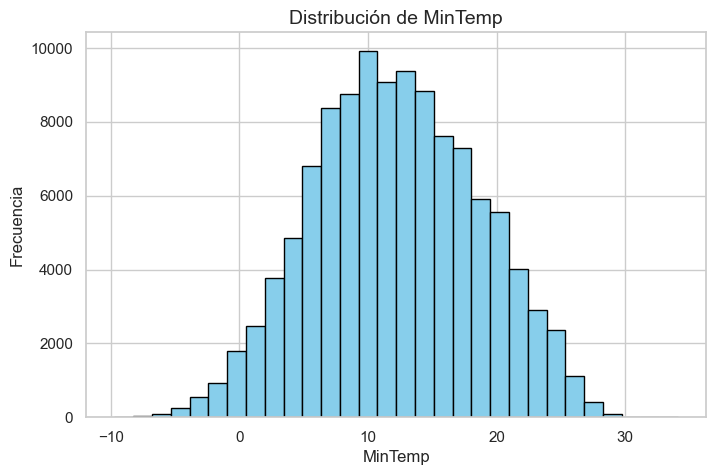

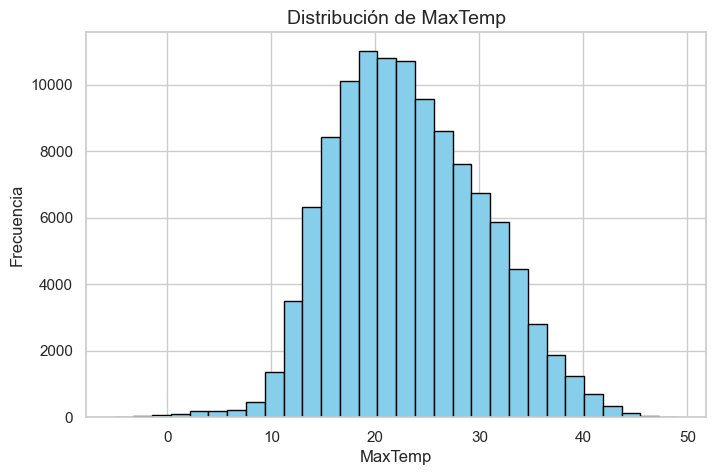

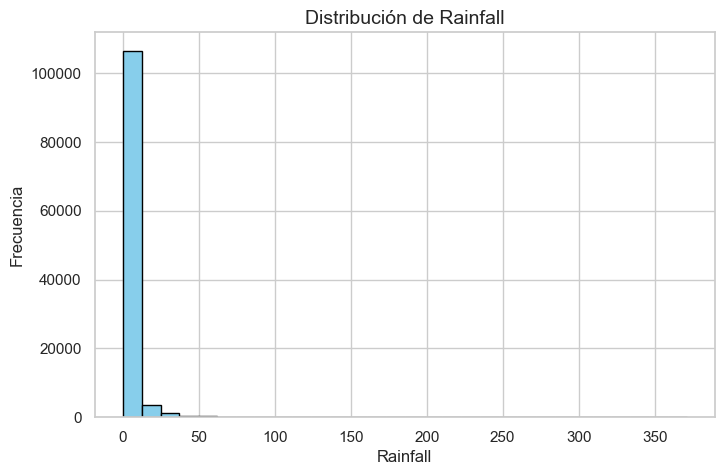

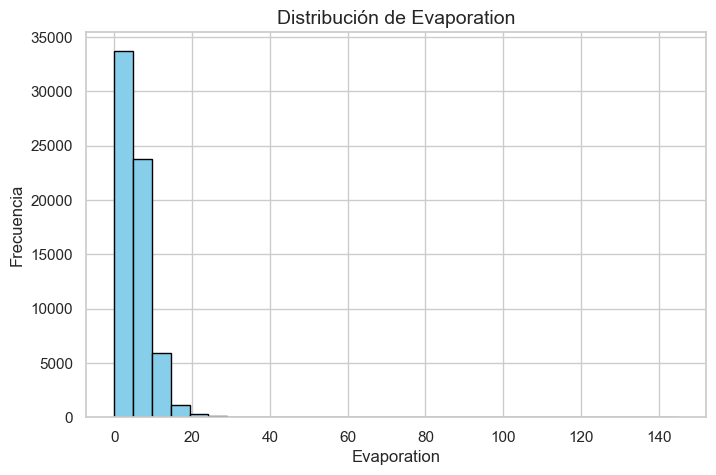

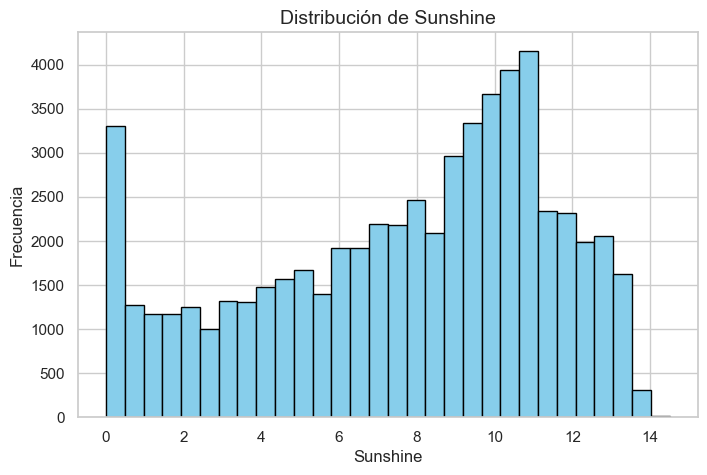

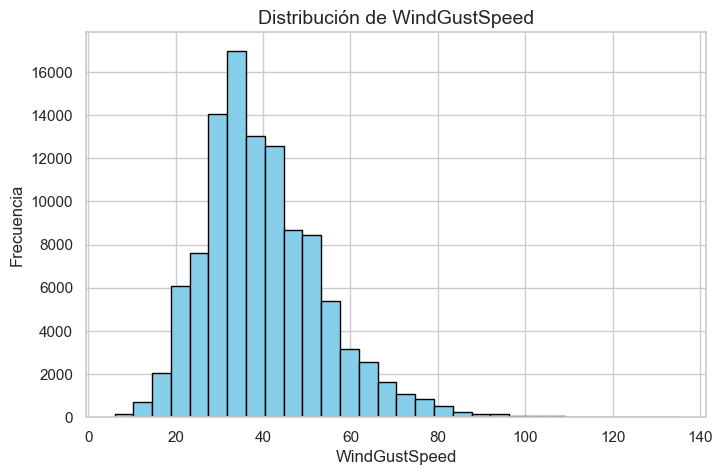

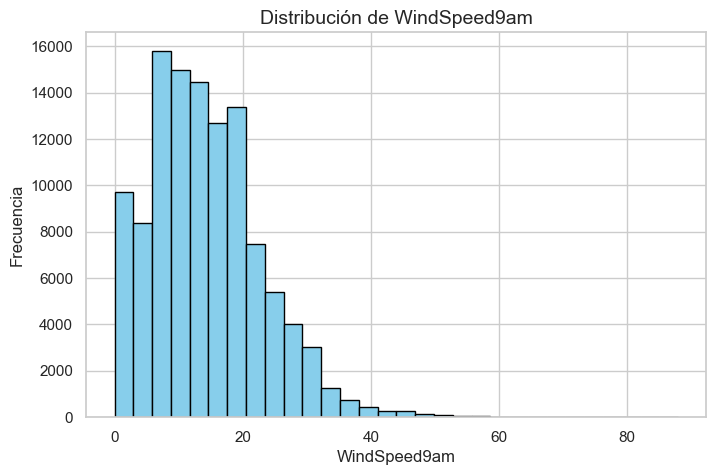

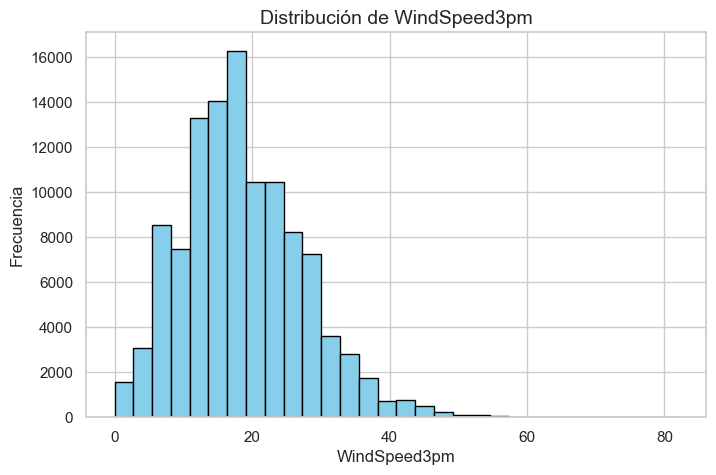

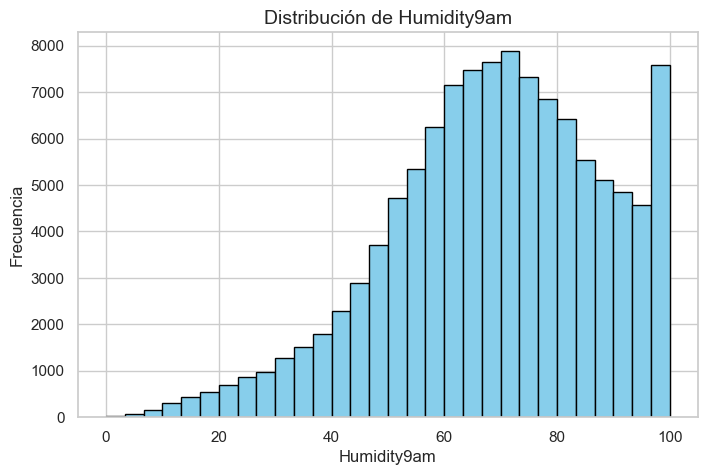

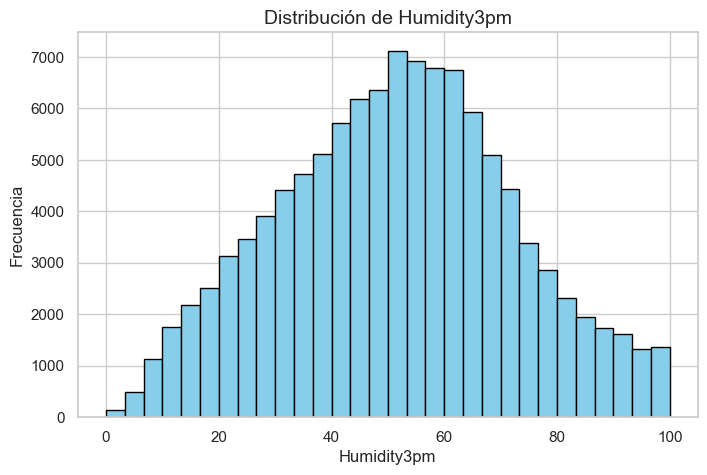

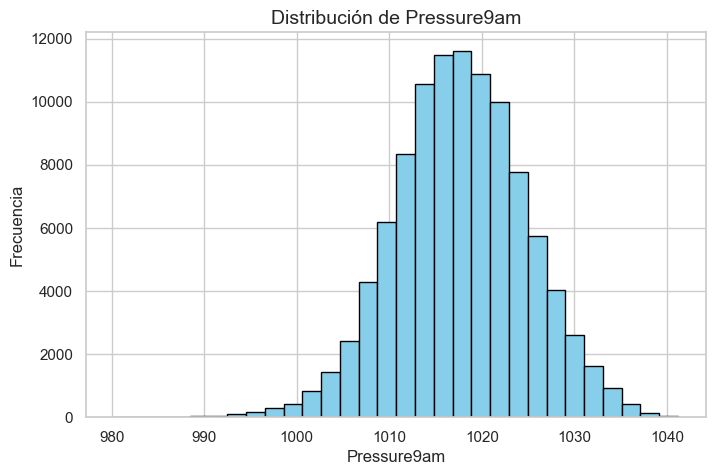

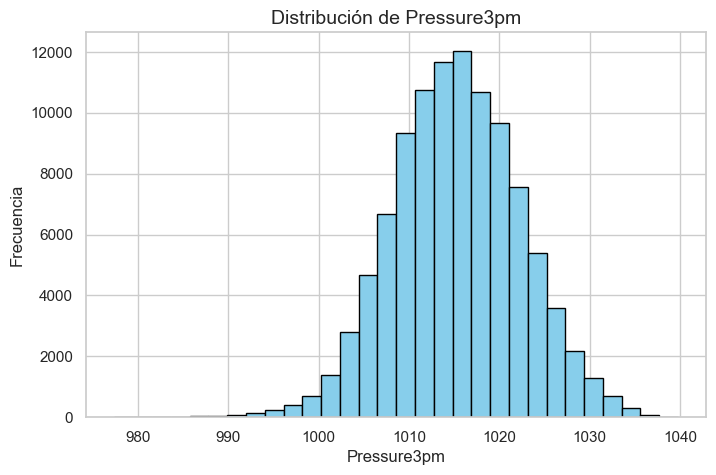

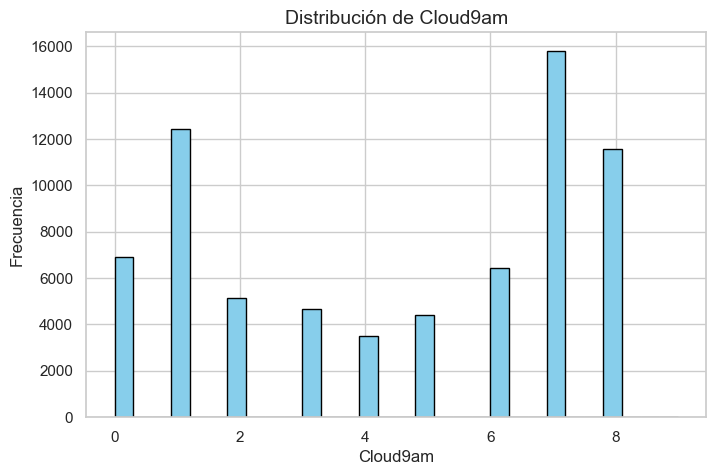

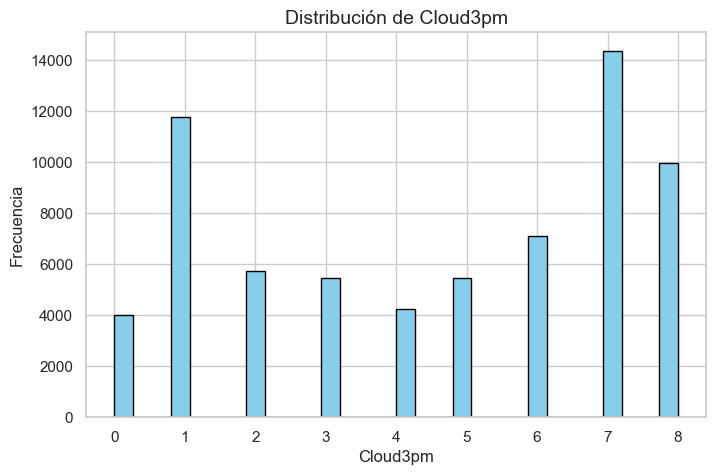

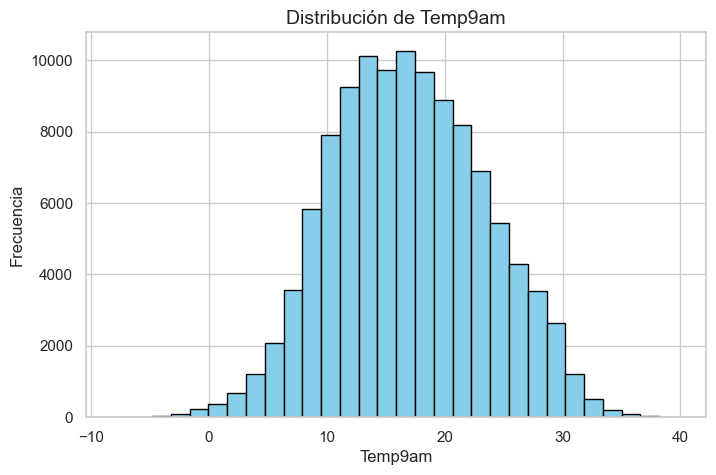

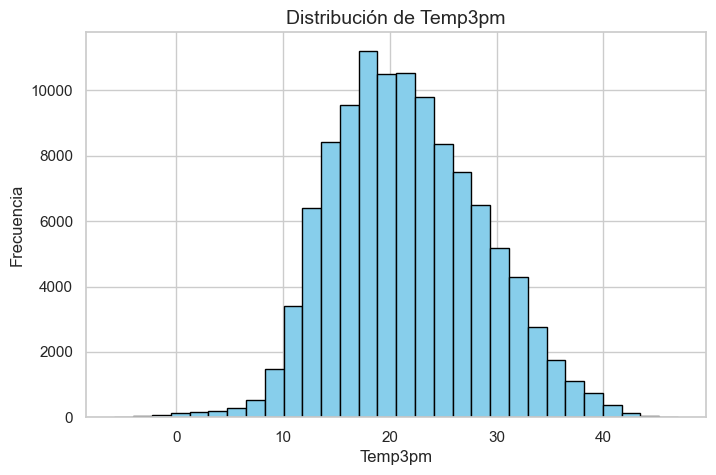

In [48]:
import matplotlib.pyplot as plt

# Hacemos un for para graficar variable por variable
for col in cols_num:
    plt.figure(figsize=(8, 5)) 
    X_train[col].hist(bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Distribución de {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show() 

En las distribuciones de las variables numéricas se observan distribuciones simétricas en la mayoría de los casos, excepto en las variables 'Rainfall' y 'Evaporation', donde se ve una asimetría hacia la derecha.

---
#### Variables Categóricas

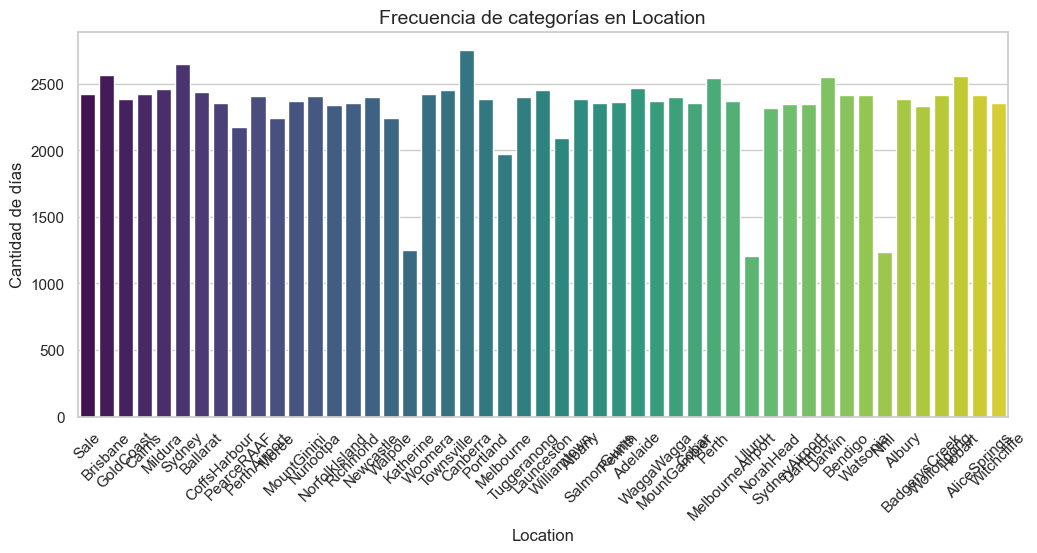

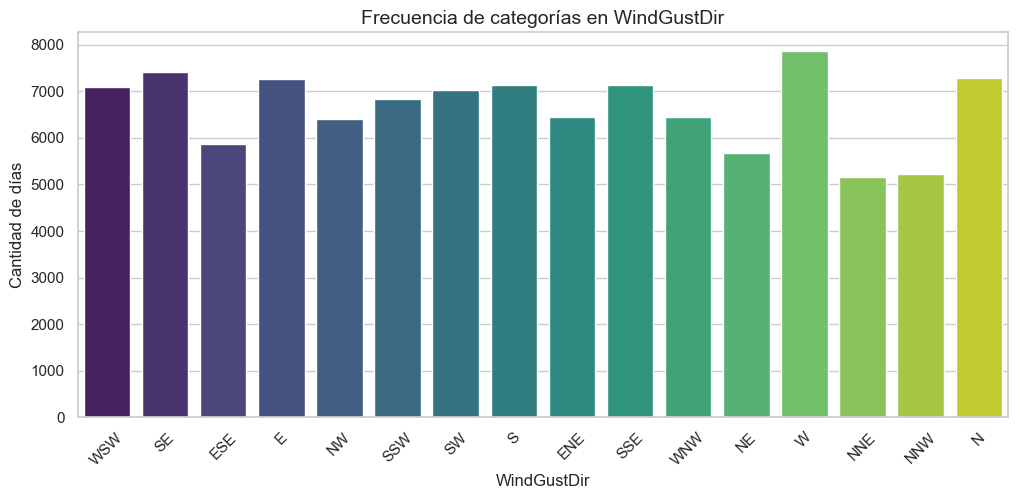

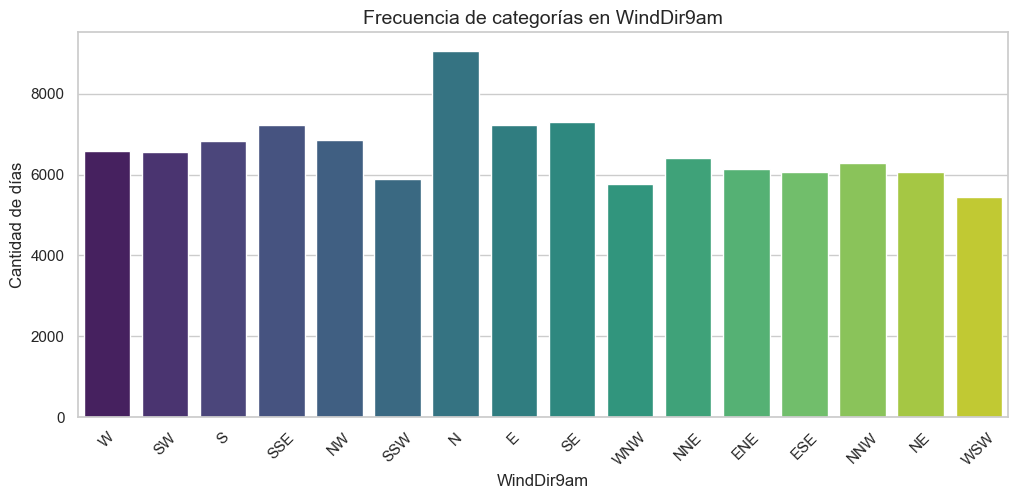

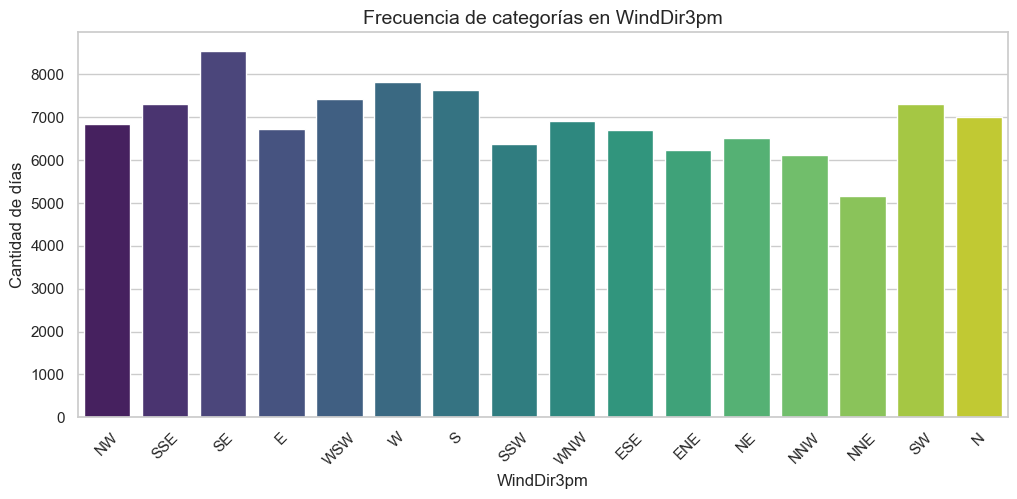

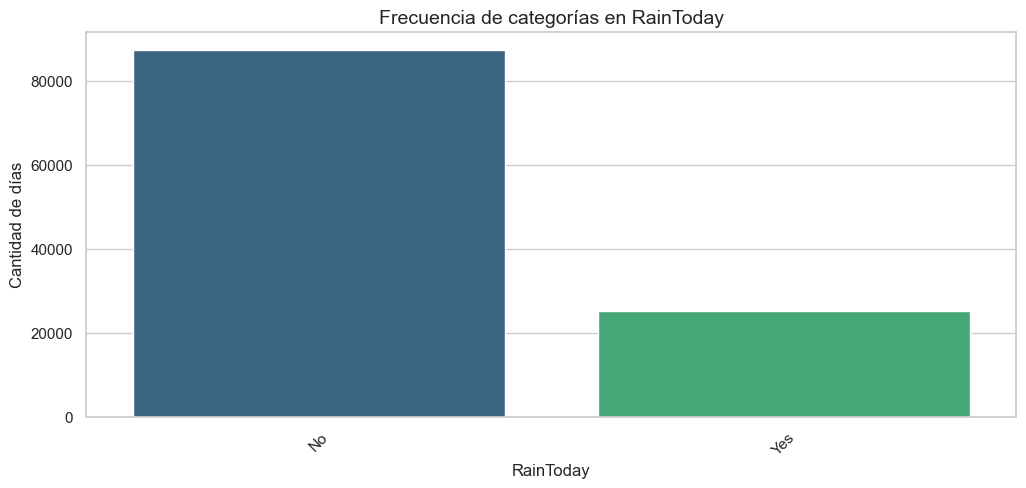

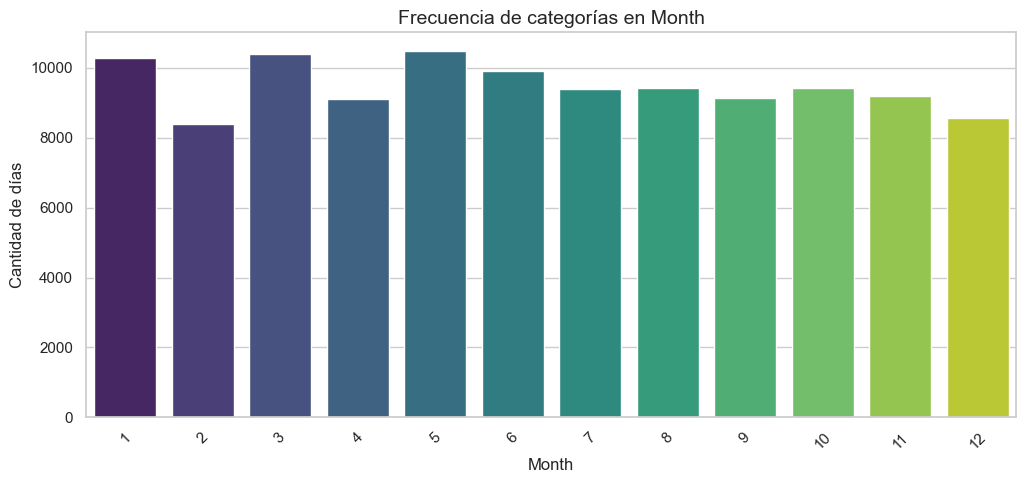

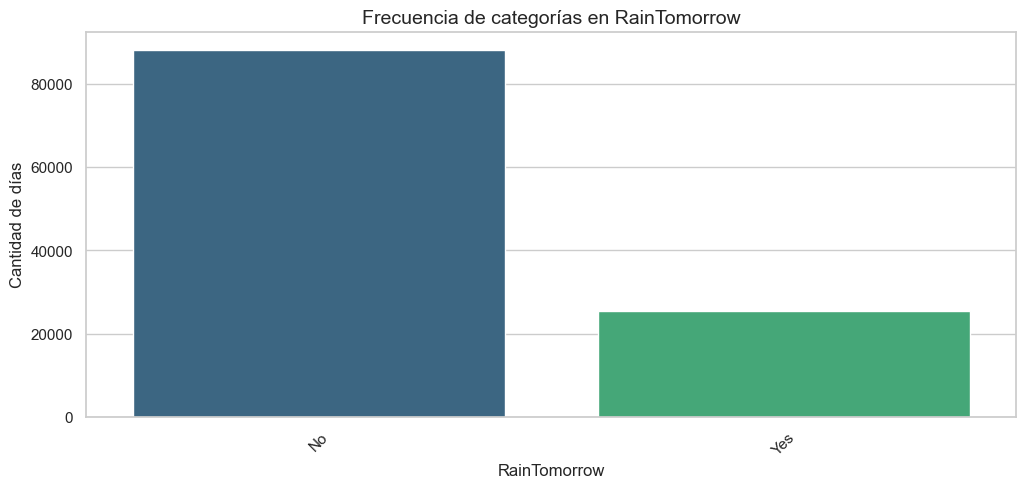

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_cat_target = cols_cat + target

# 2. Hacemos un for para graficar barras
for col in cols_cat_target:
    plt.figure(figsize=(12, 5)) 
    sns.countplot(data=df_train, x=col, palette='viridis')
    plt.title(f'Frecuencia de categorías en {col}', fontsize=14)
    plt.xticks(rotation=45) 
    plt.ylabel('Cantidad de días')
    plt.show()

Se observa que variables como Location o WindDir tienen alta cardinalidad. Al observar la distribución de RainTomorrow se concluye que el dataset está fuertemente desbalanceado. Creemos que es importante saber esto ya que el desbalanceo afecta al modelo y en caso de estarlo probablemente se deba hacer un paso extra para balancear las clases.

---
### Limpieza el Dataset

---
#### Imputación

In [ ]:
# Para los números usamos la mediana (menos sensible a outliers)
imputer_num = SimpleImputer(strategy='median')
# Para los textos usamos la moda (el valor que más se repite)
imputer_cat = SimpleImputer(strategy='most_frequent')

# Fit_transform: aprende la mediana del train y rellena el train
X_train[cols_num] = imputer_num.fit_transform(X_train[cols_num])
# Transform: rellena el test con la misma mediana que aprendió del train 
X_test[cols_num] = imputer_num.transform(X_test[cols_num])

# Rellenamos las categóricas
X_train[cols_cat] = imputer_cat.fit_transform(X_train[cols_cat])
X_test[cols_cat] = imputer_cat.transform(X_test[cols_cat])

# Chequeo de seguridad: tiene que dar 0 y 0
print("NaNs restantes en X_train:", X_train.isna().sum().sum())
print("NaNs restantes en X_test:", X_test.isna().sum().sum())


NaNs restantes en X_train: 0
NaNs restantes en X_test: 0


Para imputar los valores nulos, se utiliza la mediana de las variables numéricas (menos sensible a outliers que la media). Y se utiliza la categoría más frecuente para imputar los nulos de las variables categóricas.
En ambos casos, se usa fit transform para el conjunto train, pero solo transform para el conjunto test, esto para que el test se impute con los valores calculados en train, y así evitar fuga de datos.

---
### Codificación de Variables Categóricas

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# --- CODIFICACIÓN (One-Hot Encoding) ---
# Lo aplicamos al dataset antes del escalado.
X_train = pd.get_dummies(X_train, columns=cols_cat, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cols_cat, drop_first=True)

# Aseguramos que X_train y X_test tengan las mismas columnas (por si en Test falta alguna ciudad que estaba en Train)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Pasamos la target a 1 y 0
y_train = y_train.map({'Yes': 1, 'No': 0})
y_test = y_test.map({'Yes': 1, 'No': 0})

print(f'Dimensiones de X_Train: {X_train.shape}')
print(f'Dimensiones de X_Test: {X_test.shape}')

Dimensiones de X_Train: (113722, 121)
Dimensiones de X_Test: (28431, 121)


---
### Matriz de Correlación

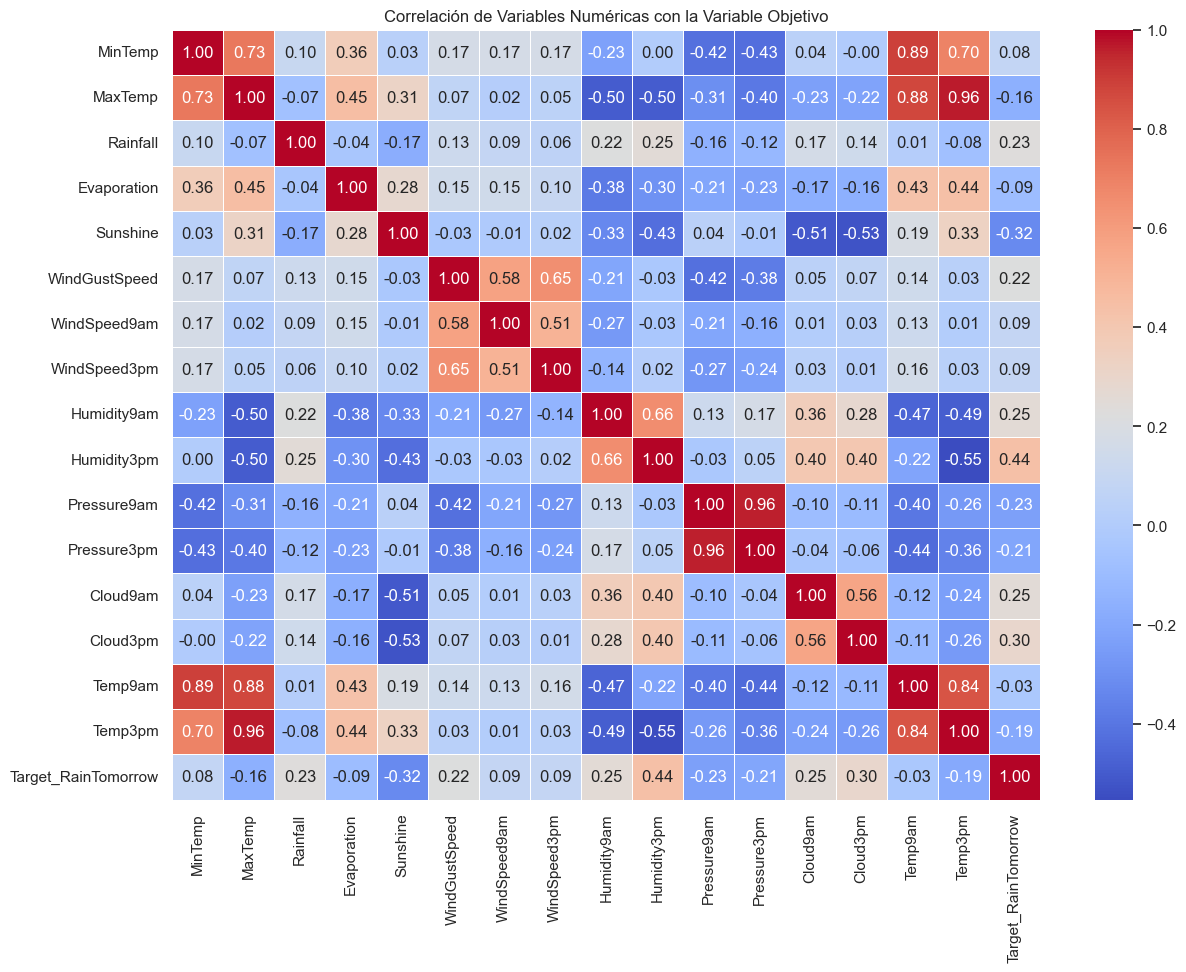

In [58]:
# --- MATRIZ DE CORRELACIÓN (Incluyendo la Variable Objetivo) ---
plt.figure(figsize=(14, 10))

# Unimos temporalmente las numéricas con la target para el gráfico
# Usamos y_train que ya mapeamos a 1 y 0
df_corr = X_train[cols_num].copy()
df_corr['Target_RainTomorrow'] = y_train

# Graficamos
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlación de Variables Numéricas con la Variable Objetivo")
plt.show()

En la matriz de correlación se observan algunos aspectos:

La variable objetivo tiene mayor correlación positiva con Humidity3pm y Cloud3pm. Por el contrario muestra correlación negativa con Sunshine. Esto indica que la humedad y la ausencia de sol son los principales precursores de lluvia para el día siguiente.

Por otro lado se detecta Multicolinealidad, dada la alta correlación entre variables explicativas como MinTemp y Temp9am, MaxTemp y Temp3pm, Pressure9am y Pressure3pm. Esto sugiere redundancia en los datos, pero al no querer identificar las variables que más explican la variable objetivo, se decide no removerlas.

---
### Escalado

In [ ]:
from sklearn.preprocessing import StandardScaler

# Creamos el escalador
scaler = StandardScaler()

# Entrenamos y transformamos el Train (solo las numéricas)
X_train[cols_num] = scaler.fit_transform(X_train[cols_num])

# Transformamos el Test con lo aprendido del Train
X_test[cols_num] = scaler.transform(X_test[cols_num])

# Chequeo final de seguridad
print("Media de MinTemp en Train (debe ser aprox 0):", X_train['MinTemp'].mean().round(2))
print("Desviación estándar de MinTemp en Train (debe ser 1):", X_train['MinTemp'].std().round(2))

Media de MinTemp en Train (debe ser aprox 0): -0.0
Desviación estándar de MinTemp en Train (debe ser 1): 1.0


---
## Clasificación con Regresión Logística

---
### Sin Balancear

---
#### Entrenamiento del Modelo

In [ ]:
# Creación del modelo
model = LogisticRegression(random_state=42)

# Entrenamiento del modelo
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

---
#### Test

In [ ]:
# Predicción en conjunto test
y_pred = model.predict(X_test)

---
#### Métricas

In [ ]:
# Cálculo de las métricas del modelo

accuracy_logreg = accuracy_score(y_test, y_pred)

confusion_matrix_logreg = confusion_matrix(y_test, y_pred)

classification_report_logreg = classification_report(y_test, y_pred)

# Imprimir métricas

print("Métricas para logreg:")
print(f'Exactitud: {accuracy_logreg}')
print('-'*20)
print("Matriz de confusión:")
print(confusion_matrix_logreg)
print('-'*20)
print("Reporte de clasificación:")
print(classification_report_logreg)

Métricas para logreg:
Exactitud: 0.8468573036474271
--------------------
Matriz de confusión:
[[20839  1218]
 [ 3136  3238]]
--------------------
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.87      0.94      0.91     22057
           1       0.73      0.51      0.60      6374

    accuracy                           0.85     28431
   macro avg       0.80      0.73      0.75     28431
weighted avg       0.84      0.85      0.84     28431



Tras obtener las métricas, se observa una exactitud (accuracy) del 85%. Si bien este número parece muy alto, el análisis detallado por categorías revela que el modelo está fuertemente influenciado por el desbalanceo de los datos (hay muchos más días sin lluvia que con lluvia en el dataset).

El modelo es excelente para predecir los días en los que no llueve (clase 0), con un recall de 0.94. Esto infla la exactitud general del modelo.

Para la clase "Sí llueve" (clase 1), el recall baja a 0.51. Esto significa que el modelo solo logra detectar la mitad de las lluvias reales.

Falsos negativos significa que el modelo predijo que no iba a llover y llovió, mientras que falsos positivos significa que el modelo predijo que llovería y no llovió.

---
#### Curvas ROC-AOC

In [68]:
# Obtengo las probabilidades de predicción del modelo
y_probs = model.predict_proba(X_test)[:, 1]

# Calculo la ROC y el AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

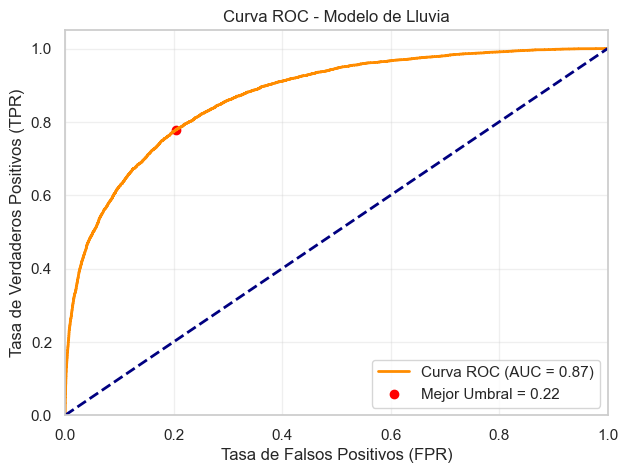

El Área bajo la Curva (AUC) es: 0.8710
El mejor umbral calculado es: 0.2196


In [69]:
# Cálculo del Mejor Umbral 
# Buscamos el punto donde la diferencia entre TPR y FPR es máxima
idx_optimo = np.argmax(tpr - fpr)
mejor_umbral = thresholds[idx_optimo]

# Graficamos la curva ROC (usando el estilo de tu clase)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# Marcamos el punto del mejor umbral
plt.scatter(fpr[idx_optimo], tpr[idx_optimo], color='red', label='Mejor Umbral = %0.2f' % mejor_umbral)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Modelo de Lluvia')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"El Área bajo la Curva (AUC) es: {roc_auc:.4f}")
print(f"El mejor umbral calculado es: {mejor_umbral:.4f}")

El modelo alcanzó un AUC de 0.87, lo que confirma una excelente capacidad discriminatoria para distinguir entre días lluviosos y secos.
A partir de maximizar la diferencia entre TPR y FPR, se determinó que el umbral óptimo es 0.22. Mientras que el umbral estándar de 0.5 penalizaba el Recall (0.51) generando muchos Falsos Negativos, este nuevo umbral sugiere que bajar la vara de decisión permite capturar una mayor cantidad de días de lluvia, logrando un modelo mucho más sensible y útil para la prevención climática.

Consideramos que se ha logrado un buen fitting. El modelo no presenta overfitting, ya que mantiene un alto desempeño (AUC 0.87) sobre el conjunto de test, demostrando capacidad de generalización. La diferencia en las métricas de cada clase no se debe a un mal ajuste, sino al desbalanceo del dataset.

---
### Dataset Balanceado

---
#### Entrenamiento del Modelo

In [70]:
model_balanced = LogisticRegression(class_weight='balanced', random_state=42)

model_balanced.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

---
#### Test

In [73]:
y_pred_balanced = model_balanced.predict(X_test)

---
#### Métricas

In [74]:
accuracy_logreg_b = accuracy_score(y_test, y_pred_balanced)

confusion_matrix_logreg_b = confusion_matrix(y_test, y_pred_balanced)

classification_report_logreg_b = classification_report(y_test, y_pred_balanced)

# Imprimir métricas
print("Métricas para logreg:")
print(f'Exactitud: {accuracy_logreg_b}')
print('-'*20)
print("Matriz de confusión:")
print(confusion_matrix_logreg_b)
print('-'*20)
print("Reporte de clasificación:")
print(classification_report_logreg_b)

Métricas para logreg:
Exactitud: 0.7925503851429777
--------------------
Matriz de confusión:
[[17627  4430]
 [ 1468  4906]]
--------------------
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86     22057
           1       0.53      0.77      0.62      6374

    accuracy                           0.79     28431
   macro avg       0.72      0.78      0.74     28431
weighted avg       0.83      0.79      0.80     28431



|Métrica | Modelo Original (0.5) | Modelo Balanceado|
|--------|-----------------------|------------------|
|Accuracy | 85% | 79%|
|Recall (Lluvia) | 51% | 77%|
|Falsos Negativos | 3.136 | 1.468|

Aunque la exactitud bajó un poco, el modelo balanceado es mucho mejor porque detecta casi el 80% de las lluvias. Redujimos a la mitad los Falsos Negativos. Si bien disminuyó la precisión para los días de lluvia, es preferible predecir que llueve y que no se cumpla, a que se dé la situación inversa.

---
#### Curva ROC-AUC

In [75]:
# Obtengo las probabilidades de predicción del modelo
y_probs_b = model_balanced.predict_proba(X_test)[:, 1]

# Calculo la ROC y el AUC
fpr_b, tpr_b, thresholds_b = roc_curve(y_test, y_probs_b)
roc_auc_b = auc(fpr_b, tpr_b)

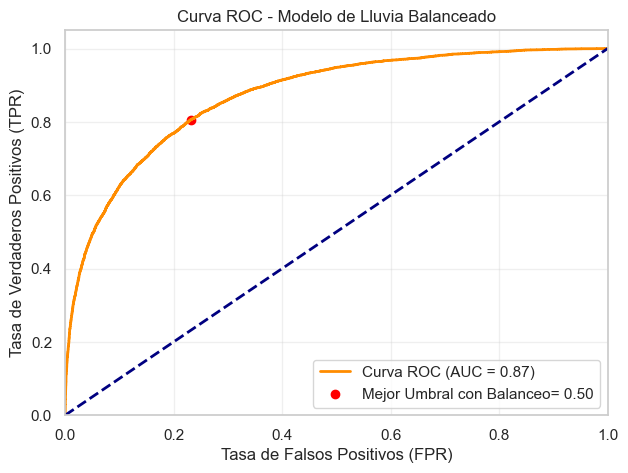

El Área bajo la Curva (AUC) es: 0.8715
El mejor umbral calculado es: 0.4980


In [76]:
# Cálculo del Mejor Umbral 
# Buscamos el punto donde la diferencia entre TPR y FPR es máxima
idx_optimo_b = np.argmax(tpr_b - fpr_b)
mejor_umbral_b = thresholds_b[idx_optimo]

# Graficamos la curva ROC (usando el estilo de tu clase)
plt.figure(figsize=(7, 5))
plt.plot(fpr_b, tpr_b, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc_b)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# Marcamos el punto del mejor umbral
plt.scatter(fpr_b[idx_optimo_b], tpr_b[idx_optimo_b], color='red', label='Mejor Umbral con Balanceo= %0.2f' % mejor_umbral_b)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Modelo de Lluvia Balanceado')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"El Área bajo la Curva (AUC) es: {roc_auc_b:.4f}")
print(f"El mejor umbral calculado es: {mejor_umbral_b:.4f}")

Al entrenar el modelo con balanceo, el umbral óptimo se desplazó hacia el 0.50. Esto demuestra que el modelo ya está compensando internamente el desbalanceo de los datos, logrando su punto de mayor equilibrio sin necesidad de forzar umbrales externos bajos como en el caso anterior.

Consideramos que se ha logrado un buen fitting también en este caso por el valor alto de AUC, y también se mejora el recall para la clase 1 (lluvia), debido al balanceo.

---
## Modelo Base

In [77]:
# Buscamos la clase mayoritaria

clase_mayoritaria = y_train.value_counts().idxmax()
print(f"La clase mayoritaria identificada es: {clase_mayoritaria} (No llueve)")

# 2. Implementamos el modelo base: clasificar todos los ejemplos en esa clase

y_pred_base = np.full(shape=y_test.shape, fill_value=clase_mayoritaria)

print("Métricas del Modelo Base (Criterio: Clase Mayoritaria):")
print(classification_report(y_test, y_pred_base, zero_division=0))

La clase mayoritaria identificada es: 0 (No llueve)
Métricas del Modelo Base (Criterio: Clase Mayoritaria):
              precision    recall  f1-score   support

           0       0.78      1.00      0.87     22057
           1       0.00      0.00      0.00      6374

    accuracy                           0.78     28431
   macro avg       0.39      0.50      0.44     28431
weighted avg       0.60      0.78      0.68     28431



A través de este análisis, se demuestra que un buen accuracy no garantiza un modelo de calidad. Es fundamental evaluar métricas adicionales como el Recall y el F1-Score para entender el desempeño sobre ambas clases por igual.

Asimismo, para la comparación de modelos se basó en el costo de los errores: en un contexto meteorológico, el impacto de un Falso Negativo (no avisar de una lluvia real) es mucho mayor que el de un Falso Positivo (dar una falsa alarma). Por lo tanto, el modelo de Regresión Logística con balanceo, al priorizar la sensibilidad para detectar tormentas, resulta ser la solución más robusta y útil para el problema planteado.